In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

In [2]:
#Constants
a,w,v,K,tau,beta,gamma=1e-3,0.8,0.024,10,30,100,10
rho=0.003
sigma_1=14
sigma_2=2
m=0.25
modFrequency=0.0034

In [3]:
#Numerical intergrator settings
t_start=0
t_end=1000000
transient=700000
t_eval=np.linspace(t_start, t_end, 1000000)

#Initial state of system
initialState=[0.1,0,1,12,0.1,0,1,12]


In [4]:

#Initial state of system


def odeModel(t,y):
    F=sigma_1*(1-(m/2)*(1+np.sin(modFrequency*t)))

    B,I,P,S,B2,I2,P2,S2=y
    B_dot=v*B*(S/(S+K)) - B*(rho+a*w*P)
    I_dot=a*w*B*P - I*(rho + 1/tau)
    P_dot=1e-6-P*(rho + a*(B+I)) + beta*(I/tau)
    S_dot=rho*(F-S) - gamma*v*B*(S/(S+K))

    B_dot2=v*B2*(S2/(S2+K)) - B2*(rho+a*w*P2)
    I_dot2=a*w*B2*P2 - I2*(rho + 1/tau)
    P_dot2=1e-6-P2*(rho + a*(B2+I2)) + beta*(I2/tau)
    S_dot2=rho*(S + sigma_2 -S2) - gamma*v*B2*(S2/(S2+K))
        
    return [B_dot,I_dot,P_dot,S_dot,B_dot2,I_dot2,P_dot2,S_dot2]

In [5]:
#Poincare section
def poincare(t, y):
    return y[4] - 0.4


In [6]:
#Solves the ODE model as well as removing transient time
def solveODE(t_s,t_e,i_state,integrator,dt,rtol,atol):
    solution = solve_ivp(odeModel,
                     [t_s,t_e],
                     i_state,method=integrator,events=poincare, t_eval=dt,rtol=rtol,atol=atol)
    eventTimes = solution.t_events[0]
    eventStates = solution.y_events[0]
    poincaretemp = eventTimes >= transient
    temp=solution.t >= transient
    poincarePoints = eventStates[poincaretemp]
    return solution.y[0][temp],solution.y[1][temp],solution.y[2][temp],solution.y[3][temp],solution.y[4][temp],solution.y[5][temp],solution.y[6][temp],solution.y[7][temp],poincarePoints,eventStates[poincaretemp]

In [7]:
#Create stable inital state
def averageSteadyState(sol):
    return np.mean(sol[0]),np.mean(sol[1]),np.mean(sol[2]),np.mean(sol[3]),np.mean(sol[4]),np.mean(sol[5]),np.mean(sol[6]),np.mean(sol[7])

In [8]:
poincare.terminal=False
poincare.direction=1
plotData=solveODE(t_start,t_end,initialState,'RK45',t_eval,1e-7,1e-10)
steadyState=averageSteadyState(plotData)
initialState2=[steadyState[0],steadyState[1],steadyState[2],steadyState[3],steadyState[4],steadyState[5],steadyState[6],steadyState[7]]
plotData2=solveODE(t_start,t_end,initialState2,'RK45',t_eval,1e-7,1e-10)


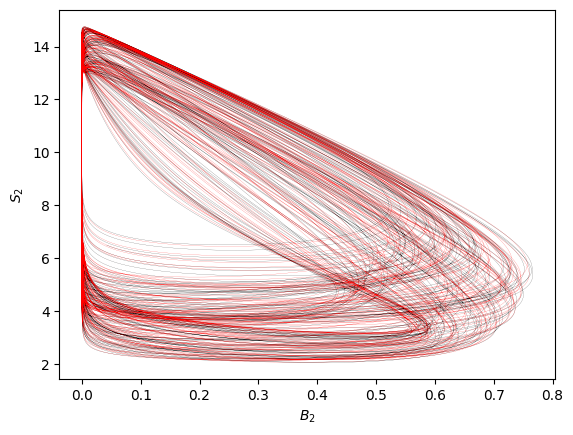

In [9]:
plt.plot(plotData[4],plotData[7],color='black',linewidth=0.1)
plt.plot(plotData2[4],plotData2[7],color='red',linewidth=0.1)
plt.xlabel("$B_2$")
plt.ylabel("$S_2$") 
plt.show()

Text(0, 0.5, '$S_2$')

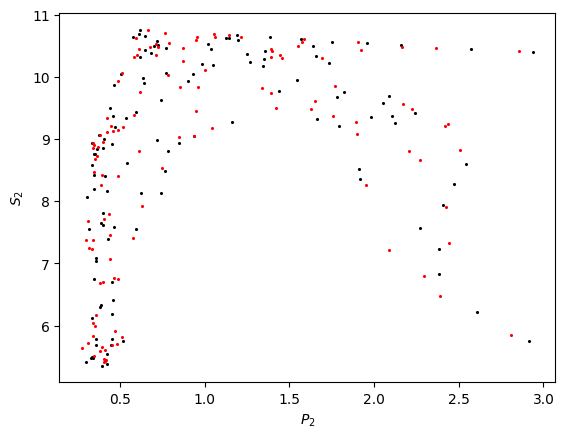

In [11]:
#poincare
poincareValues=plotData[8]
poincareValues2=plotData2[8]
I2=poincareValues[:,5]
P2=poincareValues[:,6]
S2=poincareValues[:,7]
I2_2=poincareValues2[:,5]
P2_2=poincareValues2[:,6]
S2_2=poincareValues2[:,7]
plt.scatter(P2,S2,s=1.5,color='black')
plt.scatter(P2_2,S2_2,s=1.5,color='red')
plt.xlabel("$P_2$")
plt.ylabel("$S_2$")
